# Image Classification using Multi-Layer Perceptron (MLP)
# on CIFAR-10 Dataset

In [ ]:
import keras
import numpy as np
from keras import layers

In [ ]:
# load cifar-10 dataset
from keras.datasets import cifar10
(xtrain, ytrain), (xtest, ytest) =  cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
xtrain.shape

(50000, 32, 32, 3)

In [ ]:
# cifar-10 has 10 classes
class_labels = ['airplane',
                'automobile',
                'bird',
                'cat',
                'deer',
                'dog',
                'frog',
                'horse',
                'ship',
                'truck']

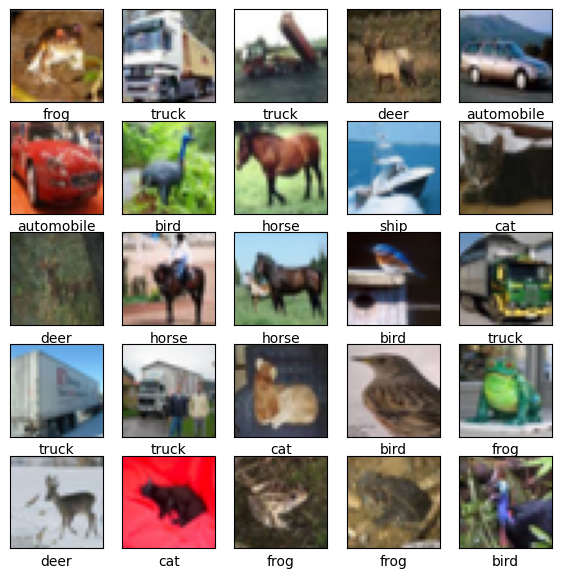

In [ ]:
# view training samples
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))

for k in range(25):
  plt.subplot(5, 5, k+1)
  plt.xticks([])
  plt.yticks([])
  plt.xlabel(class_labels[ytrain[k][0]])
  plt.imshow(xtrain[k])


# Multi-Layer Perceptron | Dense Neural Network

In [ ]:
# build multi-layer perceptron model (dense neural network)
def create_mlp():
  inputs = keras.Input(shape=(32, 32, 3))
  x = layers.Rescaling(1./255)(inputs)
  x = layers.Flatten()(x)
  x = layers.Dense(256)(x)
  x = layers.LeakyReLU(0.2)(x)
  x = layers.Dense(128)(x)
  x = layers.LeakyReLU(0.2)(x)
  outputs = layers.Dense(10, activation='softmax')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
# train model
model = create_mlp()
opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(xtrain, ytrain, epochs=10, shuffle=True, batch_size=32)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.3384 - loss: 1.8515
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4064 - loss: 1.6810
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.4348 - loss: 1.6015
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.4523 - loss: 1.5527
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4689 - loss: 1.5074
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.4822 - loss: 1.4711
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4929 - loss: 1.4389
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5024 - loss: 1.4129
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5112 - loss: 1.3885
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5192 - loss: 1.3654


In [ ]:
z = model.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


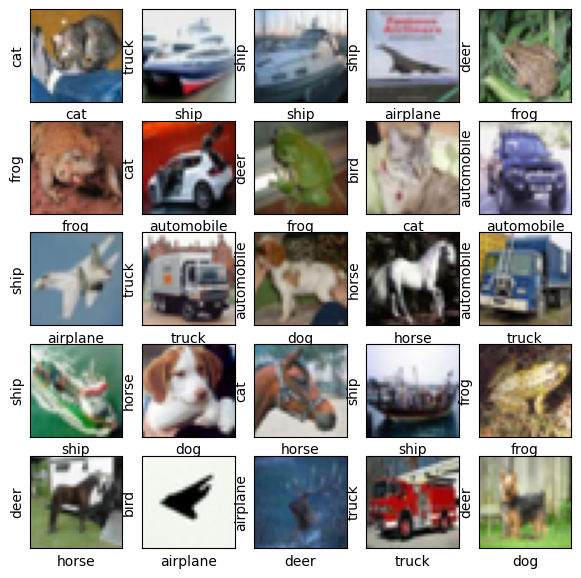

In [ ]:
# check model output on test samples

plt.figure(figsize=(7, 7))

for k in range(25):
  plt.subplot(5, 5, k+1)
  plt.xticks([])
  plt.yticks([])
  label = ytest[k][0]
  plt.xlabel(class_labels[label])
  label = np.argmax(z[k])
  plt.ylabel(class_labels[label])
  plt.imshow(xtest[k])